In [30]:
import autoroot
import tacoreader
from shapely import wkb
import numpy as np
import geopandas as gpd

import torch

from src.finetuning.model import UNetAutoencoder
import matplotlib.pyplot as plt



In [7]:
version = "1"

In [10]:
ckpt_path = "version_"+version+"/checkpoints/"
ckpt_path = "/home/emiliano/Documents/ISP/Athens_winter_school/ch10-3d-hurricane-generation/weights/"+ckpt_path
ckpt_path

'/home/emiliano/Documents/ISP/Athens_winter_school/ch10-3d-hurricane-generation/weights/version_1/checkpoints/'

In [11]:
# see what files are inside ckpt_path
import os

ckpts = os.listdir(ckpt_path)
ckpts.remove("last.ckpt")
ckpts
# split string by ""
idx = np.argmin([float(ckpt.split("=")[2].split(".ckpt")[0]) for ckpt in ckpts])
best_ckpt = ckpts[idx]
best_ckpt = ckpt_path + best_ckpt
best_ckpt

'/home/emiliano/Documents/ISP/Athens_winter_school/ch10-3d-hurricane-generation/weights/version_1/checkpoints/ae-epoch=079-val_loss=0.0163.ckpt'

In [12]:
model = UNetAutoencoder.load_from_checkpoint(best_ckpt)

/home/emiliano/anaconda3/envs/minclouds/lib/python3.11/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [13]:
import pickle
dir_save = "/home/emiliano/Documents/3DClouds_data/pickle_batches/finetune"

with open(f"{dir_save}/batch_0.pkl", "rb") as f:
    batch = pickle.load(f)
batch.keys()

dict_keys(['image', 'cloudsat', 'overpass_mask', 'satellite', 'date', 'id'])

In [15]:
# pass batch through model
output = model(batch["image"])
output.shape

torch.Size([4, 3, 80, 256, 256])

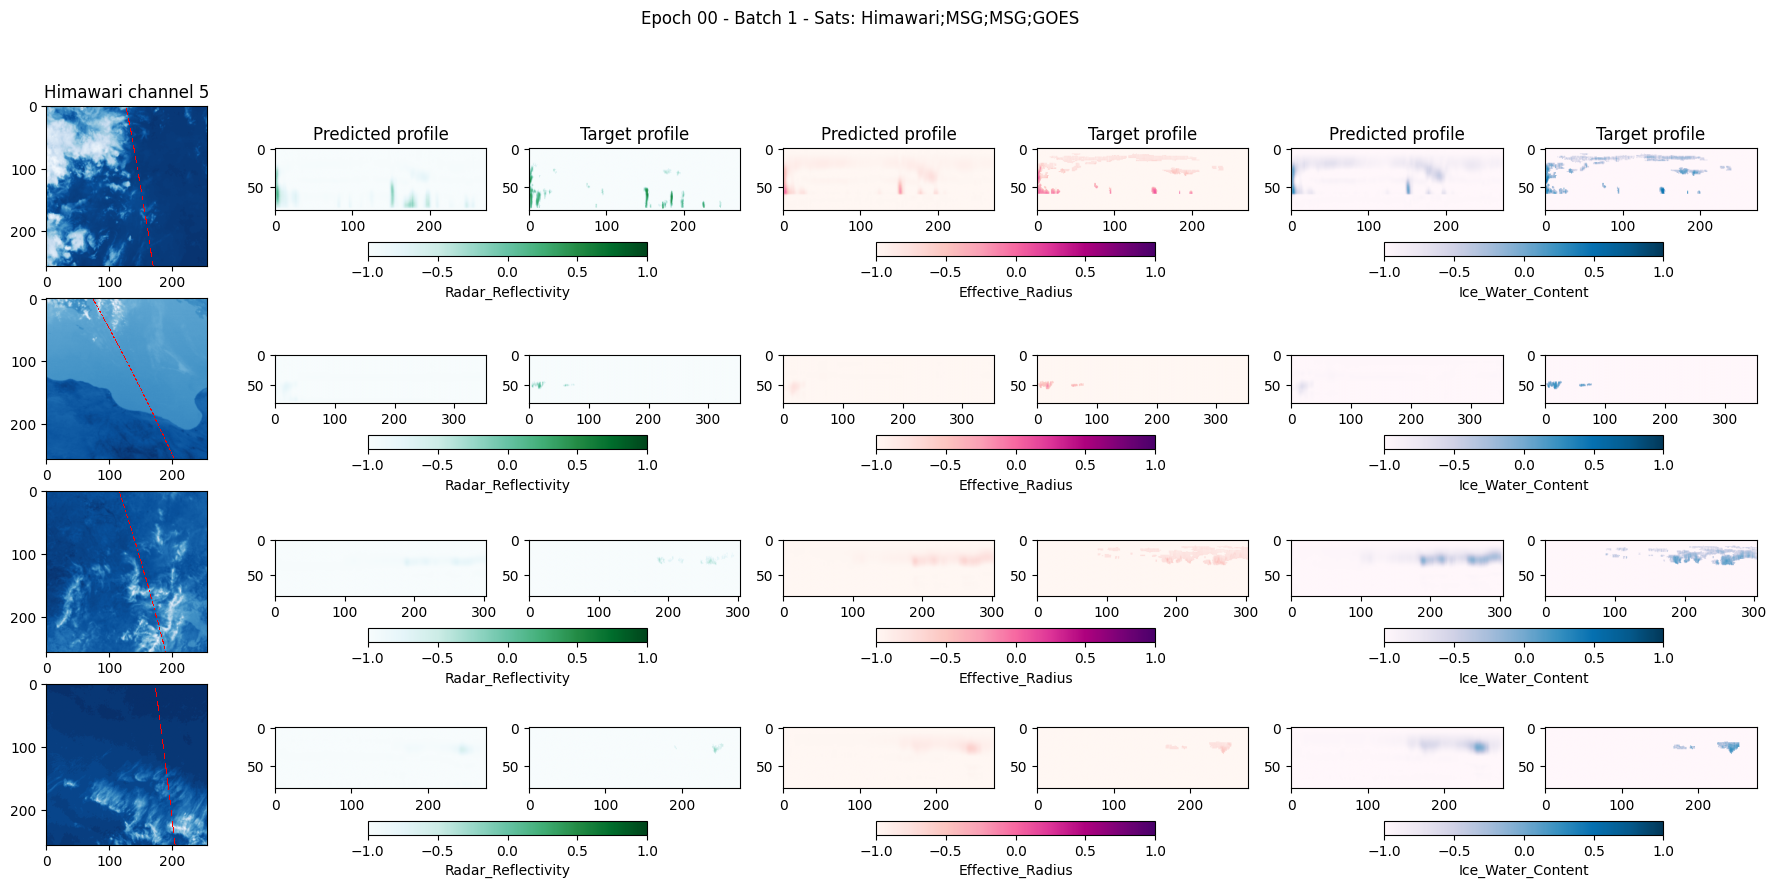

In [16]:
# plot using plot_predictions function
fig = model.plot_multi_profiles(batch, output, batch_idx=1)

In [17]:
from src.finetuning.metrics import get_profiles 

In [18]:
batch.keys()

dict_keys(['image', 'cloudsat', 'overpass_mask', 'satellite', 'date', 'id'])

In [19]:
cs = batch["cloudsat"]
cs_p = output 
overpass_mask = batch["overpass_mask"]

In [21]:
cs.shape

torch.Size([4, 3, 512, 80])

In [22]:
cs_p.shape

torch.Size([4, 3, 80, 256, 256])

In [23]:
overpass_mask.shape

torch.Size([4, 256, 256])

In [26]:
var = 0
cs_profiles, cs_p_profiles = get_profiles(cs[:,var].permute(0, 2, 1), cs_p[:,var], overpass_mask)

In [37]:
cs_profiles[1].shape

torch.Size([80, 354])

In [38]:
cs_p_profiles[1].shape    

torch.Size([80, 354])

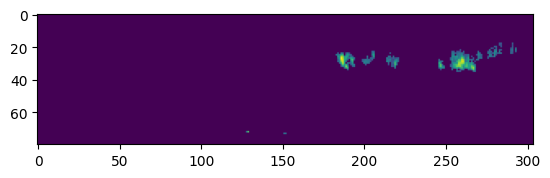

In [39]:
plt.imshow(cs_profiles[2])

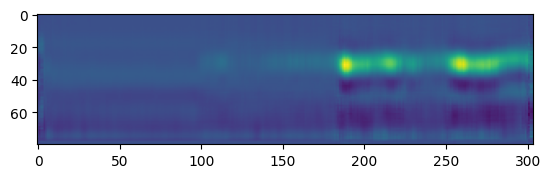

In [40]:
plt.imshow(cs_p_profiles[2].detach().numpy())

In [41]:
import torch.nn as nn

In [42]:
mse = nn.MSELoss(reduction="mean")


In [43]:
mse(cs_profiles[0], cs_p_profiles[0])

tensor(0.0178, grad_fn=<MseLossBackward0>)